We will perform K-means to cluster based only on text reclamation

In [7]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OneHotEncoder



# Load cleaned data
df = pd.read_csv("../data/Reclamations_clean.csv")

In [8]:
tfidf = TfidfVectorizer(
    min_df=1,        # safest setting
    ngram_range=(1, 2)
)

X = tfidf.fit_transform(df['texte_reclamation'].tolist())

Optimal k selected by elbow method: 5


C:\Users\wassi\AppData\Local\Temp\ipykernel_30816\2383086704.py:18: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)


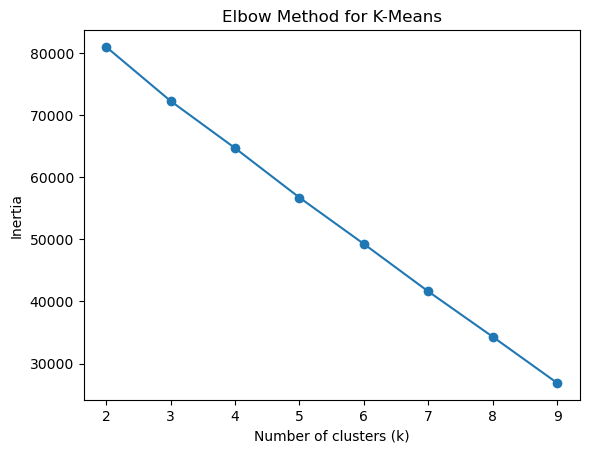

In [9]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

# Coordinates of all points
points = np.column_stack((list(K_range), inertia))

# Line between first and last point
start = points[0]
end = points[-1]

# Distance from each point to the line
def distance_to_line(point, start, end):
    return np.abs(np.cross(end - start, start - point)) / np.linalg.norm(end - start)

distances = [distance_to_line(p, start, end) for p in points]

# Elbow is the point with maximum distance
optimal_k = K_range[np.argmax(distances)]

print("Optimal k selected by elbow method:", optimal_k)

# Plot elbow curve
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means")
plt.show()

In [10]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

In [11]:
terms = tfidf.get_feature_names_out()
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(optimal_k):
    print(f"\nCluster {i} top terms:")
    for ind in order_centroids[i, :8]:
        print(terms[ind], end=" | ")


Cluster 0 top terms:
ne | ne se | synchronise pas | synchronise | modem ne | modem | se synchronise | se | 
Cluster 1 top terms:
lors | lors de | de la | de | la | authentification | connexion | la connexion | 
Cluster 2 top terms:
en soirée | faible | très | débit très | très faible | en | débit | soirée | 
Cluster 3 top terms:
sur | demande | figée sur | figée | image figée | certaines chaines | certaines | chaines | 
Cluster 4 top terms:
installation non | délais | réalisée dans | réalisée | non réalisée | non | les délais | les | 

In [12]:
df[['texte_reclamation', 'cluster']].head(10)

,texte_reclamation,cluster
0,Incident: modem ne se synchronise pas.,0
1,Client signale problème lors de la résiliation...,1
2,Demande d'assistance: bruit important sur la l...,3
3,"Incident: problème lors de la résiliation, fac...",1
4,Incident: installation non réalisée dans les d...,4
5,Demande d'assistance: image figée sur certaine...,3
6,Demande d'assistance: montant facturé incorrec...,3
7,"Réclamation: montant facturé incorrectement, d...",3
8,Client signale demande d'information sur l'off...,3
9,Réclamation: erreur d'authentification lors de...,1


now we will perform K-Means on the categorical data : using partitional clustering

In [13]:
features = ['category', 'region', 'sentiment']
df = df[features].dropna()

In [14]:
encoder = OneHotEncoder(handle_unknown='ignore')

X = encoder.fit_transform(df)

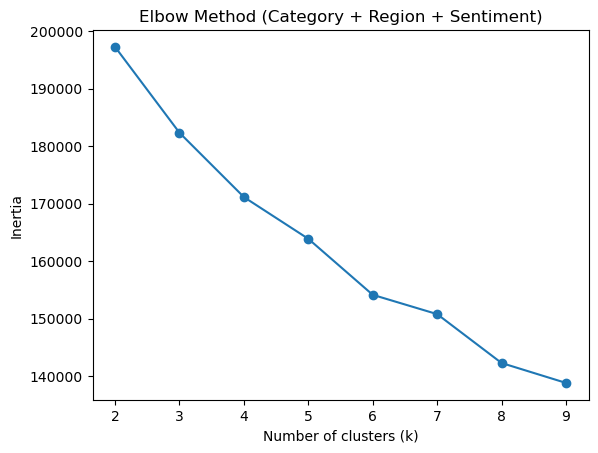

In [15]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method (Category + Region + Sentiment)")
plt.show()

In [16]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df['cluster'] = kmeans.fit_predict(X)

In [ ]:
pd.crosstab(df['cluster'], df['category'])


category,Assistance,Autre,Configuration,Coupure De Ligne,Facturation,Installation,Internet Lent,Problème Matériel,Résiliation,Télévision
cluster,,,,,,,,,,
0,4735,1180,2385,13471,7213,5906,0,3455,3646,6054
1,2331,582,1147,6692,3530,2978,5947,1836,1834,3006
2,842,204,422,2212,1148,987,1965,588,621,961
3,0,0,0,0,0,0,12122,0,0,0


In [ ]:
pd.crosstab(df['cluster'], df['region'])


In [ ]:
pd.crosstab(df['cluster'], df['sentiment'])